In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import shap

d:\forecasting\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv(
    "../data/feature_engineered_data.csv"
)

df["Date"] = pd.to_datetime(
    df["Date"]
)

In [3]:
feature_cols = [

    "Store","Dept",

    "Type","Size",

    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",

    "MarkDown1",
    "MarkDown2",
    "MarkDown3",
    "MarkDown4",
    "MarkDown5",

    "IsHoliday",

    "Year",
    "Month",
    "Quarter",
    "Week",

    "lag_1",
    "lag_2",
    "lag_4",
    "lag_8",

    "rolling_mean_4",
    "rolling_std_4",
    "rolling_mean_8"
]

In [4]:
split_date = "2012-02-01"

test_df = df[
    df["Date"] >= split_date
]

X_test = test_df[
    feature_cols
]

y_test = test_df[
    "Weekly_Sales"
]

In [5]:
model = joblib.load(
    "../models/xgb_forecasting_model.pkl"
)
preds = model.predict(X_test)

mae = mean_absolute_error(
    y_test,
    preds
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        preds
    )
)

r2 = r2_score(
    y_test,
    preds
)

print("MAE:",mae)
print("RMSE:",rmse)
print("R2:",r2)

MAE: 1442.8362102530139
RMSE: 3038.8138892437314
R2: 0.981231060157724


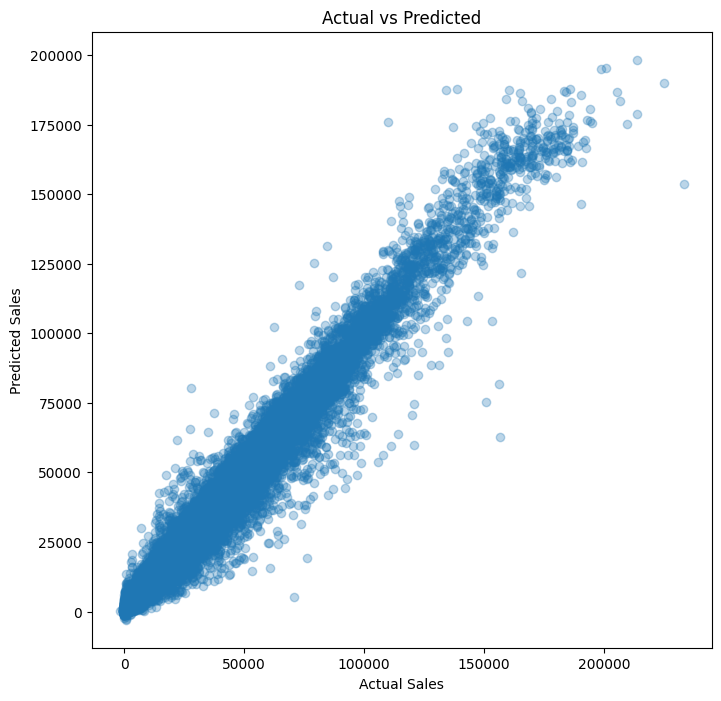

In [6]:
plt.figure(
    figsize=(8,8)
)

plt.scatter(
    y_test,
    preds,
    alpha=0.3
)

plt.xlabel(
    "Actual Sales"
)

plt.ylabel(
    "Predicted Sales"
)

plt.title(
    "Actual vs Predicted"
)

plt.show()

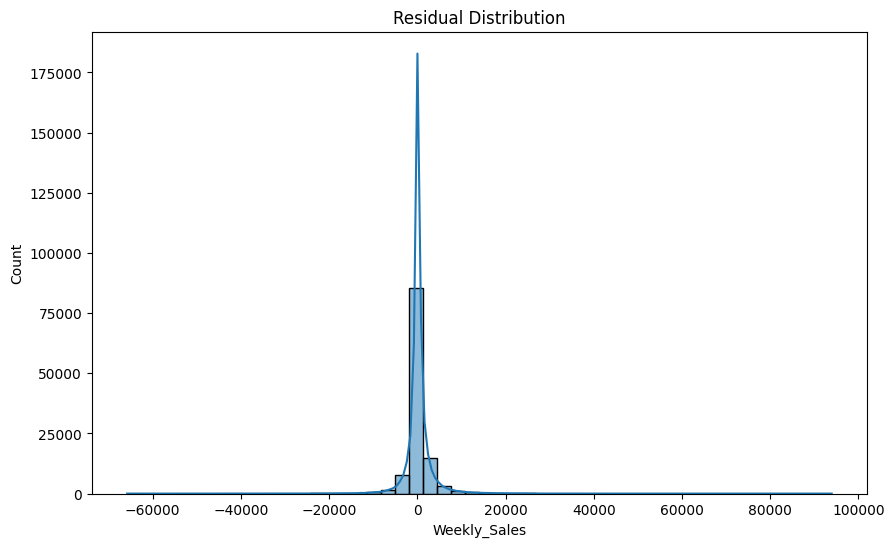

In [7]:
residuals = y_test - preds
plt.figure(
    figsize=(10,6)
)

sns.histplot(
    residuals,
    bins=50,
    kde=True
)

plt.title(
    "Residual Distribution"
)

plt.show()

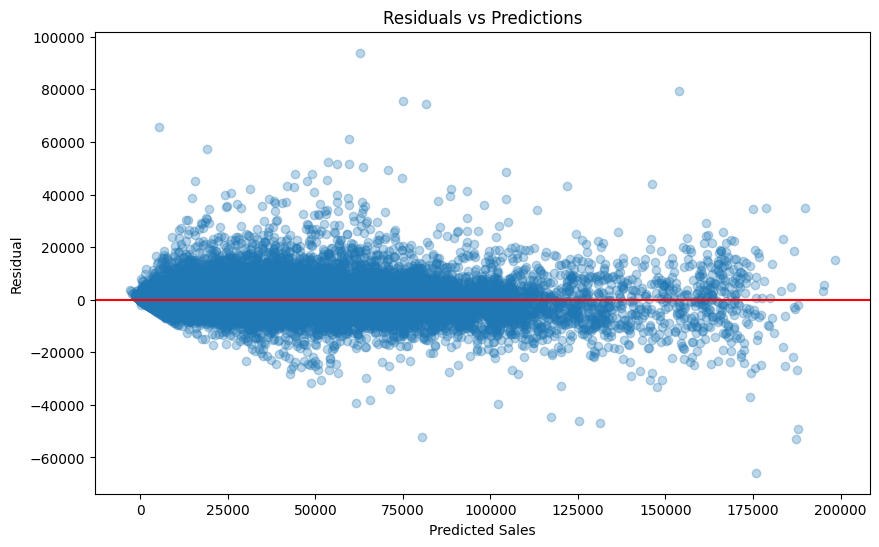

In [8]:
plt.figure(
    figsize=(10,6)
)

plt.scatter(
    preds,
    residuals,
    alpha=0.3
)

plt.axhline(
    y=0,
    color="red"
)

plt.xlabel(
    "Predicted Sales"
)

plt.ylabel(
    "Residual"
)

plt.title(
    "Residuals vs Predictions"
)

plt.show()

In [9]:
importance = pd.DataFrame({

    "Feature":feature_cols,

    "Importance":
    model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

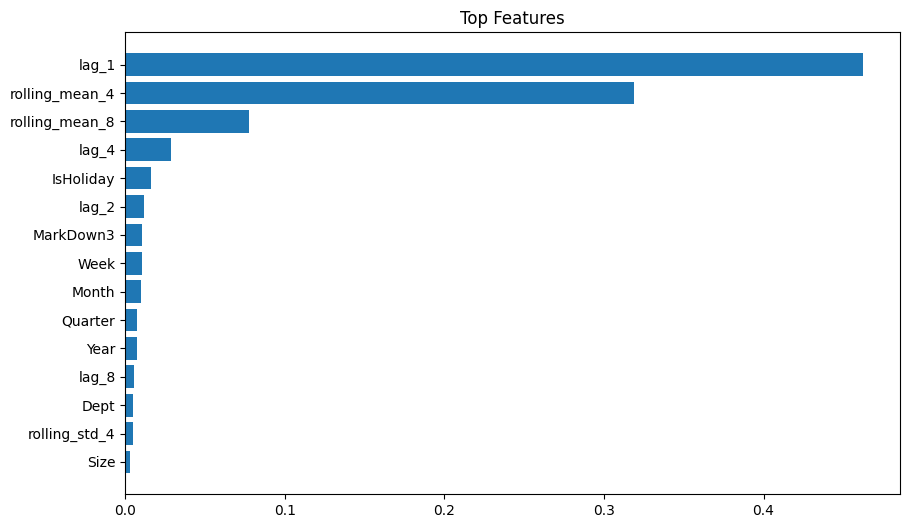

In [10]:
plt.figure(
    figsize=(10,6)
)

plt.barh(
    importance["Feature"][:15],
    importance["Importance"][:15]
)

plt.gca().invert_yaxis()

plt.title(
    "Top Features"
)

plt.show()

In [11]:
explainer = shap.TreeExplainer(
    model
)

sample = X_test.sample(
    1000,
    random_state=42
)

shap_values = explainer.shap_values(
    sample
)

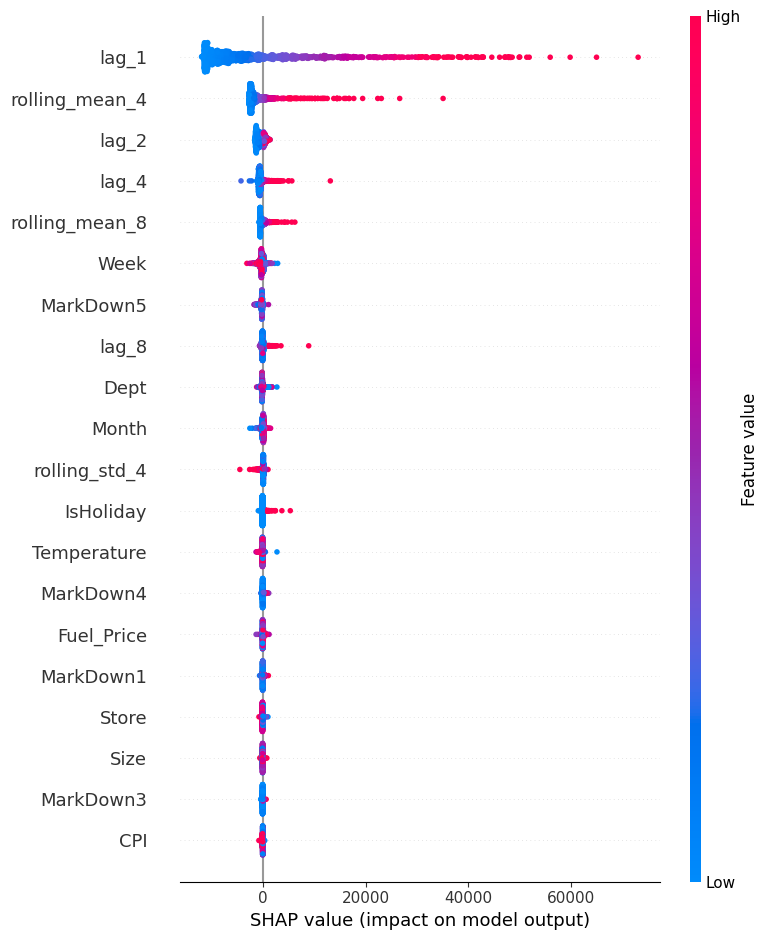

In [12]:
shap.summary_plot(
    shap_values,
    sample
)

In [13]:
test_df = test_df.copy()

test_df[
    "Predicted"
] = preds

store_error = (
    test_df
    .groupby("Store")
    .apply(
        lambda x:
        mean_absolute_error(
            x["Weekly_Sales"],
            x["Predicted"]
        )
    )
)

store_error = store_error.reset_index()

store_error.columns = [
    "Store",
    "MAE"
]

store_error.sort_values(
    by="MAE",
    ascending=False
).head(10)

,Store,MAE
19,20,2624.058901
13,14,2551.148841
12,13,2152.154352
3,4,2147.478764
22,23,2139.841256
26,27,2124.103323
9,10,2073.634233
1,2,2011.885309
18,19,1965.716611
27,28,1938.384150


In [14]:
dept_error = (
    test_df
    .groupby("Dept")
    .apply(
        lambda x:
        mean_absolute_error(
            x["Weekly_Sales"],
            x["Predicted"]
        )
    )
)

dept_error = dept_error.reset_index()

dept_error.columns = [
    "Dept",
    "MAE"
]

dept_error.sort_values(
    by="MAE",
    ascending=False
).head(10)

,Dept,MAE
36,38,5593.432558
59,72,5369.692778
72,92,4967.841599
75,95,3726.338879
56,65,3494.063594
14,16,3042.898651
0,1,2983.829283
8,9,2769.339086
6,7,2618.724047
4,5,2560.113808
